In [1]:
from cordobaDataPreprocessor import *
from cordobaPredictor import *
from cordobaPostProcessor import *

In [2]:
# Login info to GEE
gee_account =  "scigeo@ee-jfloresf17.iam.gserviceaccount.com"
gee_credentials_path = "../../credentials.json"

# The dates T1 and T2
days = ['2021-01-01', '2022-12-31']

# Coordinates
coordinates = [
          [
            [
              -62.994113850390036,
              -29.81677755001185
            ],
            [
              -63.01955941169891,
              -29.83684560350636
            ],
            [
              -63.02341479977622,
              -29.859082986730712
            ],
            [
              -62.9968126220443,
              -29.87713676641895
            ],
            [
              -62.96095751292722,
              -29.867274458306092
            ],
            [
              -62.940716720052535,
              -29.836176731759267
            ],
            [
              -62.957713648971705,
              -29.8062834483545
            ],
            [
              -62.98701459835719,
              -29.800596170529722
            ],
            [
              -62.994113850390036,
              -29.81677755001185
            ]
          ]
        ]

In [3]:
# The area of interest, here goes the conversion ee.Geometry -> LongLatBBox
# when Julieta will have done it
area_of_interest = LongLatBBox(coordinates[0])

# Create a preprocessor instance
preprocessor = CordobaDataPreprocessor(gee_account, gee_credentials_path)

# Get the satellite images using sentinel-2 data and compositing over
# one window of 10 days around the requested dates
preprocessor.nb_max_step_search = 1
preprocessor.step_search_image = 4
preprocessor.data_source = CordobaDataSource.DYNAMIC_WORLD
images = preprocessor.get_satellite_data(days, area_of_interest)

# Also it works with Sentinel-2
# preprocessor.step_search_image = 10
# preprocessor.data_source = CordobaDataSource.SENTINEL2
# images = preprocessor.get_satellite_data(days, area_of_interest, preprocessed_indices=["ndvi"])

data source: DYNAMIC_WORLD
image acquisition...
mode composite of 4 images...
remote preprocessing...
converting to CordobaImage...
Downloaded data shape: (847, 799, 9)
data source: DYNAMIC_WORLD
image acquisition...
mode composite of 4 images...
geometric registration...
remote preprocessing...
converting to CordobaImage...
Downloaded data shape: (847, 799, 9)


In [4]:
# Create a predictor instance
predictor = CordobaPredictor()

# Predict the deforestation using dynamic world only with a denoising
# # threshold of 0.5
# threshold_denoising = 0.5
# deforest_mask = predictor.predict_dynamic_world(images, "trees", threshold_denoising)
cva_mask = predictor.predict_CVA(images)
deforest_polygon = predictor.convert_mask_to_polygon(cva_mask, area_of_interest)

search range [0.006257683, 0.8310491]
search range [0.1712159693241119, 0.3361742556095123]
search range [0.2536951124668121, 0.2866867697238922]
search range [0.27349010682106, 0.280088438272476]
search range [0.27810893883705134, 0.2794286051273346]
search range [0.27810893883705134, 0.27837287209510797]
search range [0.2782672987918854, 0.27832008544349673]
search range [0.27830952811317455, 0.27832008544349685]
search range [0.2783126953122712, 0.27831480677833564]
optimal threshold 0.2783135398986969 for Lk 63.371378346188386


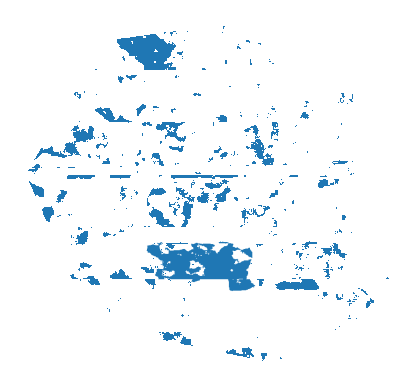

In [5]:
deforest_polygon

## Plotear el poligono usando matplotlib
import matplotlib.pyplot as plt

deforest_polygon.plot()
plt.axis("off")
plt.show()

In [ ]:
## IN DEVELOPMENT
# # Add postprocessing if necessary
# postprocess = cordobaPostProcessor()
# index_thresholds = {
#     "ndvi": -0.2,
#     "nbr": -0.3,
#     "ndmi": -0.3,
#     "savi": -0.3
# }

# deforest_polygon_postprocess = postprocess.process(images, cva_mask, index_thresholds, min_votes=3)

# # To get the mask as an image if necessary
# # from PIL import Image
# # img = Image.fromarray((deforest_mask*255.0).astype(numpy.uint8))